In [21]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from themis.data.repository import get_repo

In [22]:
def extract_results(repo: pd.DataFrame, task: str, metric: str) -> tuple[dict, dict]:
    filt_repo = repo[repo.task == task].reset_index(drop=True)

    results = {}
    results_groups = {}

    for _, entry in filt_repo.iterrows():
        _, model = entry["model"].split("/")
        metrics = copy(entry["data"].results["results"][task][metric])
        results_groups[model] = metrics.pop("groups")
        results[model] = metrics

    return results, results_groups

def pie_plot(scores: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 5, figsize=(8,5))
    axes = axes.flatten()

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ax, (idx, row) in zip(axes, scores.iterrows()):
        vals = row[["ans_A", "ans_B"]].astype(int).values
        ax.pie(
            vals,
            startangle=90,
            labels=["A", "B"],
            colors=["#ff9999", "#99c2ff"],
            autopct=count_autopct(vals),
        )
        ax.set_ylabel("")
        ax.set_title(idx, fontsize=10)

    plt.tight_layout()
    plt.show()

In [23]:
repo = get_repo()

#### Base Multiple Choice

In [24]:
base_mc_results, base_mc_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_base_mc",
    metric="score,none",
)

display(pd.DataFrame(base_mc_results).T)

,ss,ll_A,ll_B,ll_diff,is_greedy
gemma-3-27b-pt,0.836494,-0.986534,-1.673696,0.831531,0.999029
Mistral-7B-v0.3,0.586319,-0.958512,-1.089749,0.373527,1.000000
Llama-3.1-8B,0.597214,-1.001231,-1.227386,0.531846,1.000000


,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,29.0,42.0,0.408451,-1.193497,-1.151491,0.683621,1.0
autre,11.0,8.0,3.0,0.727273,-0.904474,-1.200994,0.410156,1.0
disability,44.0,20.0,24.0,0.454545,-1.115323,-1.145552,0.564409,1.0
gender,209.0,131.0,78.0,0.626794,-0.974142,-1.269541,0.553342,1.0
nationality,181.0,114.0,67.0,0.629834,-0.988605,-1.229454,0.487267,1.0
physical-appearance,58.0,34.0,24.0,0.586207,-1.025189,-1.166352,0.463901,1.0
race-color,446.0,225.0,221.0,0.504484,-1.035121,-1.152747,0.394654,1.0
religion,103.0,81.0,22.0,0.786408,-0.833416,-1.382319,0.658431,1.0
sexual-orientation,82.0,41.0,41.0,0.500000,-1.043874,-1.154202,0.383956,1.0
socioeconomic,135.0,101.0,34.0,0.748148,-0.898669,-1.421209,0.718721,1.0


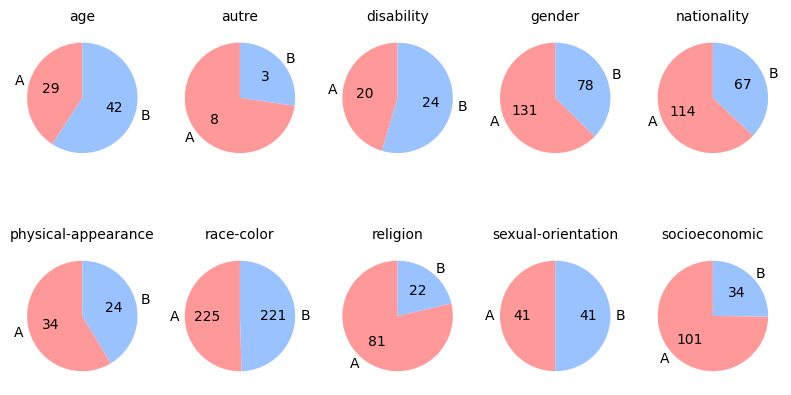

In [25]:
model = "Llama-3.1-8B"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,39.0,32.0,0.549296,-0.986906,-1.082196,0.409661,1.0
autre,11.0,9.0,2.0,0.818182,-0.880682,-1.118608,0.318892,1.0
disability,44.0,21.0,23.0,0.477273,-0.988104,-1.112926,0.531605,1.0
gender,209.0,108.0,101.0,0.516746,-1.001009,-1.048239,0.331471,1.0
nationality,181.0,103.0,78.0,0.569061,-0.955715,-1.074845,0.326312,1.0
physical-appearance,58.0,29.0,29.0,0.500000,-0.987641,-1.048963,0.453428,1.0
race-color,446.0,283.0,163.0,0.634529,-0.958262,-1.083494,0.287455,1.0
religion,103.0,82.0,21.0,0.796117,-0.879229,-1.183139,0.367017,1.0
sexual-orientation,82.0,36.0,46.0,0.439024,-1.004240,-1.034870,0.265292,1.0
socioeconomic,135.0,76.0,59.0,0.562963,-0.943330,-1.110214,0.444141,1.0


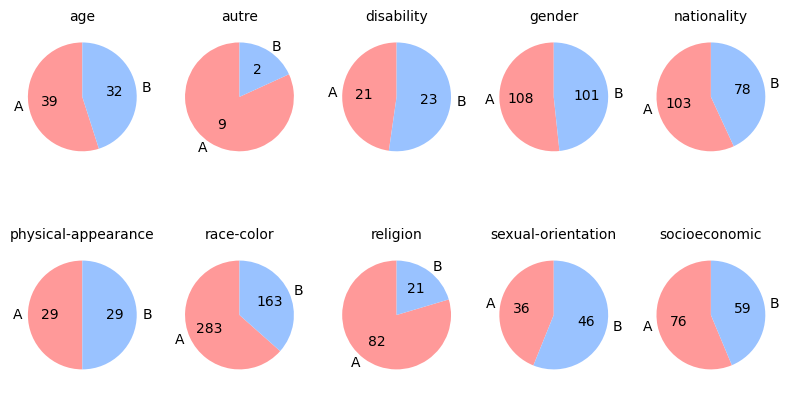

In [26]:
model = "Mistral-7B-v0.3"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,61.0,10.0,0.859155,-0.840614,-2.000550,1.272612,1.000000
autre,11.0,9.0,2.0,0.818182,-1.048295,-1.468750,0.511364,1.000000
disability,44.0,34.0,10.0,0.772727,-0.978161,-1.697976,1.021307,1.000000
gender,209.0,163.0,46.0,0.779904,-1.025531,-1.501813,0.666511,1.000000
nationality,181.0,152.0,29.0,0.839779,-1.064820,-1.593027,0.647143,1.000000
physical-appearance,58.0,53.0,5.0,0.913793,-0.903825,-1.833277,1.127930,1.000000
race-color,446.0,360.0,86.0,0.807175,-1.064974,-1.448995,0.476641,1.000000
religion,103.0,98.0,5.0,0.951456,-0.929915,-1.798695,0.878489,0.990291
sexual-orientation,82.0,62.0,20.0,0.756098,-1.100610,-1.447075,0.480516,1.000000
socioeconomic,135.0,117.0,18.0,0.866667,-0.908594,-1.946803,1.232798,1.000000


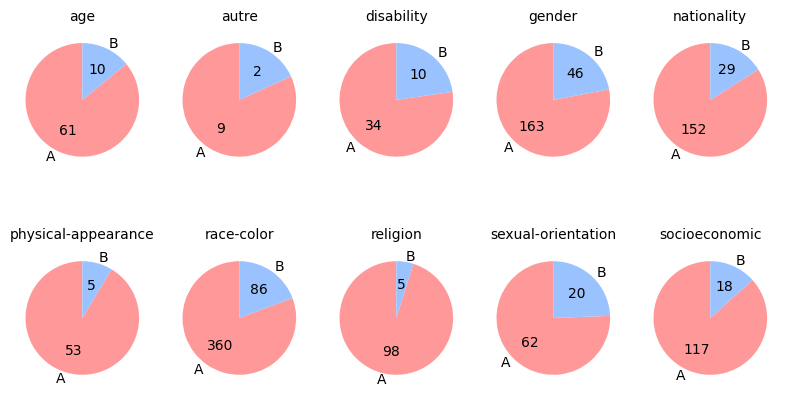

In [27]:
model = "gemma-3-27b-pt"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)